I'd like to try plotting the GSP regions from NESO so that I can then use this map to visualize data
- EPSG:4326 (longitude/latitude - very common and geojson is convenient) and EPSG:27700 (British National Grid)
- saves outputs in data/outputs/visualisations

In [12]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt

# The GeoJSON is already in longitude/latitude (EPSG:4326), which is convenient for plotting.
data_path = Path("../data/inputs/gsp_regions_20260209/Proj_4326/GSP_regions_4326_20260209.geojson")
gsp_regions = gpd.read_file(data_path)

gsp_regions.head()

,fid,GSPs,GSPGroup,SSEP17Zone,DSCPs,InGroup_,CDCA_I030,geometry
0,1,LEGA_1,_D,7,NaN,Y,=GSP_LEGA_1,"MULTIPOLYGON (((-3.67528 52.3655, -3.67033 52...."
1,2,THSO_P,_P,1,NaN,Y,=GSP_THSO_P,"MULTIPOLYGON (((-3.0732 58.73774, -3.07412 58...."
2,3,BRIM_1,_C,17,[+]BRIM_C,N,=II_BRIM_C,"MULTIPOLYGON (((0.12638 51.59359, 0.12145 51.5..."
3,4,EERH,_N,4,NaN,Y,=GSP_EERH,"MULTIPOLYGON (((-4.1545 55.84639, -4.15447 55...."
4,5,AXMI1,_L,15,NaN,Y,=GSP_AXMI1,"MULTIPOLYGON (((-2.69894 50.68317, -2.69628 50..."


In [18]:
number_of_gsp_regions = len(gsp_regions)
print(f"Number of GSP regions: {number_of_gsp_regions}")

Number of GSP regions: 362


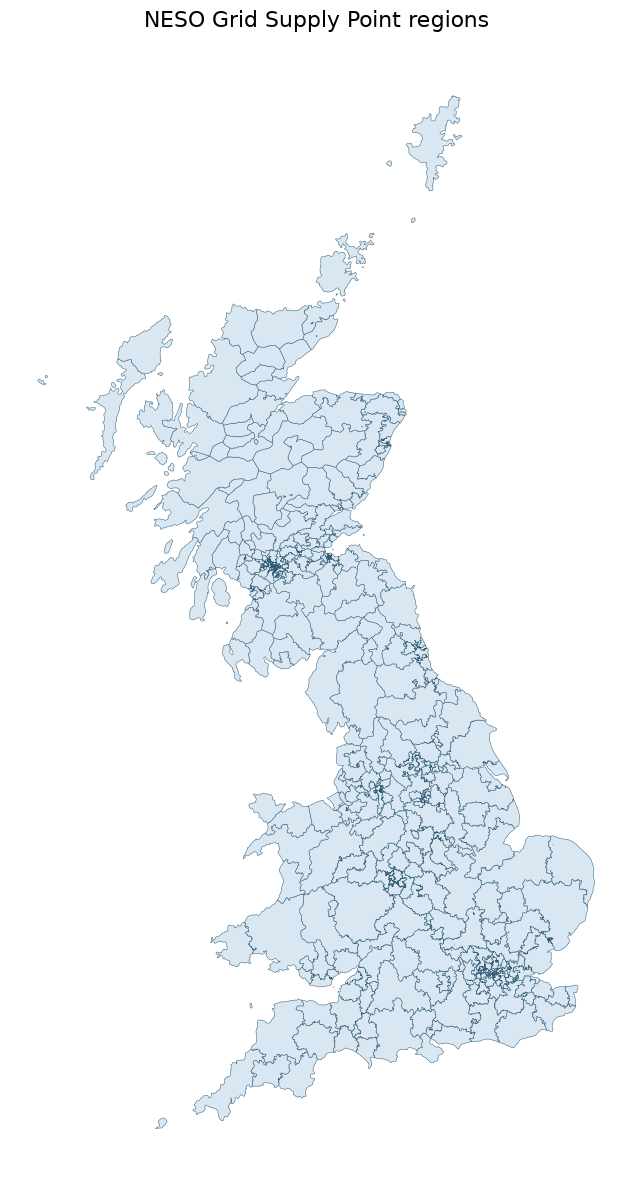

In [13]:
fig, ax = plt.subplots(figsize=(10, 12))

gsp_regions.plot(
    ax=ax,
    facecolor="#d9e7f2",
    edgecolor="#315b73",
    linewidth=0.35,
)

ax.set_title("NESO Grid Supply Point regions", fontsize=16, pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [14]:
import random

# Build an adjacency graph from shared boundary segments.
adjacent_regions = {index: set() for index in range(len(gsp_regions))}
spatial_index = gsp_regions.sindex

for region_index, geometry in enumerate(gsp_regions.geometry):
    if region_index % 25 == 0:
        print(f"Checking adjacency: region {region_index + 1}/{len(gsp_regions)}")

    for neighbour_index in spatial_index.query(geometry, predicate="touches"):
        neighbour_index = int(neighbour_index)
        if neighbour_index <= region_index:
            continue

        shared_boundary = geometry.boundary.intersection(
            gsp_regions.geometry.iloc[neighbour_index].boundary
        )
        if shared_boundary.length > 1e-10:
            adjacent_regions[region_index].add(neighbour_index)
            adjacent_regions[neighbour_index].add(region_index)

print(f"Adjacency graph ready: {sum(map(len, adjacent_regions.values())) // 2} shared boundaries")

# Random tie-breaking gives DSATUR several inexpensive chances to find a compact colouring.
colour_assignments = None
for number_of_colours in (4, 5):
    for attempt in range(1, 201):
        assignments = [-1] * len(gsp_regions)
        uncoloured_regions = set(adjacent_regions)

        while uncoloured_regions:
            saturation = {
                index: len({
                    assignments[neighbour_index]
                    for neighbour_index in adjacent_regions[index]
                    if assignments[neighbour_index] != -1
                })
                for index in uncoloured_regions
            }
            highest_saturation = max(saturation.values())
            candidates = [
                index for index in uncoloured_regions
                if saturation[index] == highest_saturation
            ]
            region_index = max(
                candidates,
                key=lambda index: (len(adjacent_regions[index]), random.random()),
            )
            unavailable_colours = {
                assignments[neighbour_index]
                for neighbour_index in adjacent_regions[region_index]
                if assignments[neighbour_index] != -1
            }
            available_colours = set(range(number_of_colours)) - unavailable_colours

            if not available_colours:
                break

            assignments[region_index] = min(available_colours)
            uncoloured_regions.remove(region_index)

        if not uncoloured_regions:
            colour_assignments = assignments
            print(
                f"{number_of_colours}-colour assignment found on attempt {attempt}"
            )
            break

        if attempt % 10 == 0:
            print(
                f"{number_of_colours}-colour attempt {attempt}/200 did not fit"
            )

    if colour_assignments is not None:
        break

assert colour_assignments is not None, "Could not colour the adjacency graph."

if number_of_colours == 5:
    print("The supplied geometries need five colours under strict shared-boundary adjacency.")

# Check that every pair of adjacent regions has different colours.
assert all(
    colour_assignments[region_index] != colour_assignments[neighbour_index]
    for region_index, neighbours in adjacent_regions.items()
    for neighbour_index in neighbours
)

plot_data = gsp_regions.assign(_colour=colour_assignments)
plot_data["_colour"].value_counts().sort_index()

Checking adjacency: region 1/362
Checking adjacency: region 26/362
Checking adjacency: region 51/362
Checking adjacency: region 76/362
Checking adjacency: region 101/362
Checking adjacency: region 126/362
Checking adjacency: region 151/362
Checking adjacency: region 176/362
Checking adjacency: region 201/362
Checking adjacency: region 226/362
Checking adjacency: region 251/362
Checking adjacency: region 276/362
Checking adjacency: region 301/362
Checking adjacency: region 326/362
Checking adjacency: region 351/362
Adjacency graph ready: 975 shared boundaries
4-colour attempt 10/200 did not fit
4-colour attempt 20/200 did not fit
4-colour attempt 30/200 did not fit
4-colour attempt 40/200 did not fit
4-colour attempt 50/200 did not fit
4-colour attempt 60/200 did not fit
4-colour attempt 70/200 did not fit
4-colour attempt 80/200 did not fit
4-colour attempt 90/200 did not fit
4-colour attempt 100/200 did not fit
4-colour attempt 110/200 did not fit
4-colour attempt 120/200 did not fit


_colour
0    106
1     90
2     88
3     71
4      7
Name: count, dtype: int64

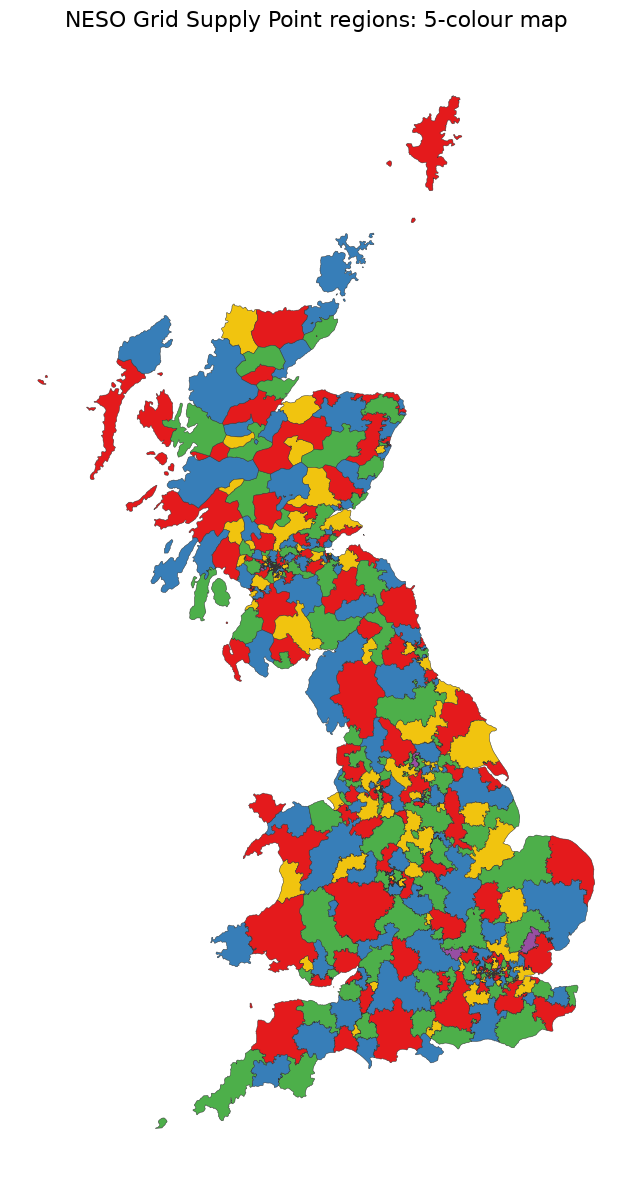

In [15]:
from matplotlib.colors import ListedColormap

colours = ["#e41a1c", "#377eb8", "#4daf4a", "#f1c40f", "#984ea3"]

fig, ax = plt.subplots(figsize=(10, 12))
plot_data.plot(
    ax=ax,
    column="_colour",
    categorical=True,
    cmap=ListedColormap(colours[:number_of_colours]),
    edgecolor="#333333",
    linewidth=0.35,
)

ax.set_title(
    f"NESO Grid Supply Point regions: {number_of_colours}-colour map",
    fontsize=16,
    pad=12,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

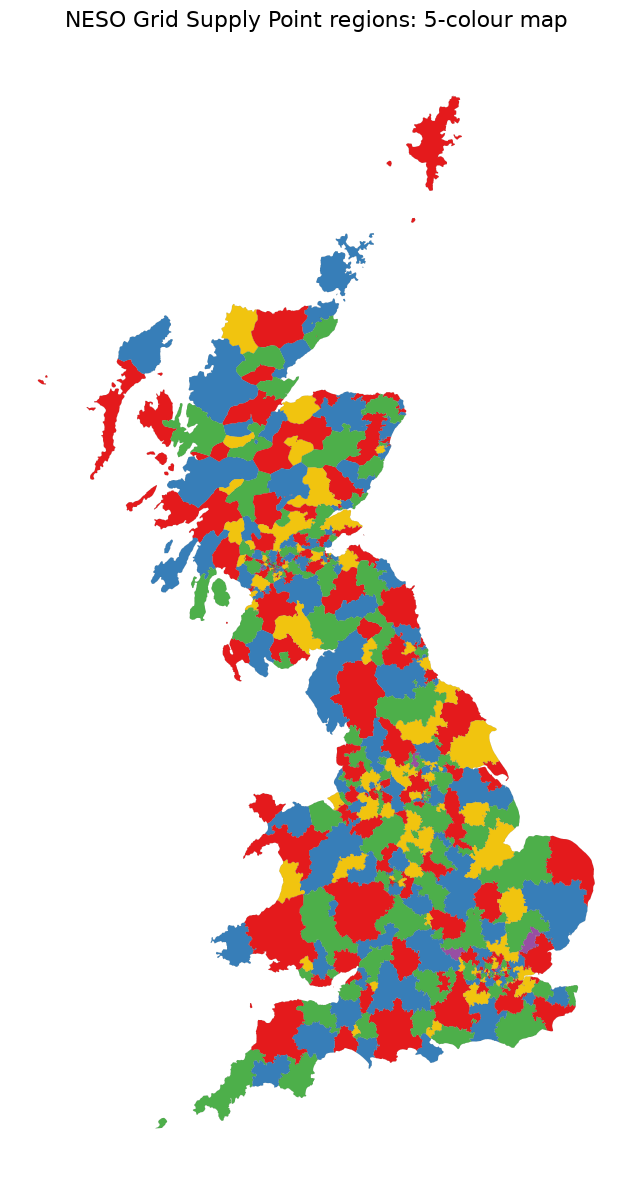

Saved vector map to: ..\data\outputs\visualisations\gsp_regions_colour_coded.svg


In [16]:
output_path = Path("../data/outputs/visualisations/gsp_regions_colour_coded.svg")
output_path.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 12))
plot_data.plot(
    ax=ax,
    column="_colour",
    categorical=True,
    cmap=ListedColormap(colours[:number_of_colours]),
    edgecolor="#333333",
    linewidth=0.05,
)

ax.set_title(
    f"NESO Grid Supply Point regions: {number_of_colours}-colour map",
    fontsize=16,
    pad=12,
)
ax.set_axis_off()
fig.tight_layout()
fig.savefig(output_path, format="svg", bbox_inches="tight")
plt.show()
print(f"Saved vector map to: {output_path}")